# 13. Cellular Automata and Emergence

A row of cells, each obeying one tiny rule about its two neighbors, weaves patterns that nobody designed. Today we build cellular automata, meet Conway's Game of Life, and add the course's key concept of **emergence**: global order that the local rules never mention.

## Today's destination

The spacetime weave of **rule 110**: one line of cells evolving downward, row by row, from a random start. Every triangle, glider and collision in this image follows from a rule that fits in eight bits, and this particular rule has been proved capable of universal computation. The picture is, quite literally, a fabric computing.

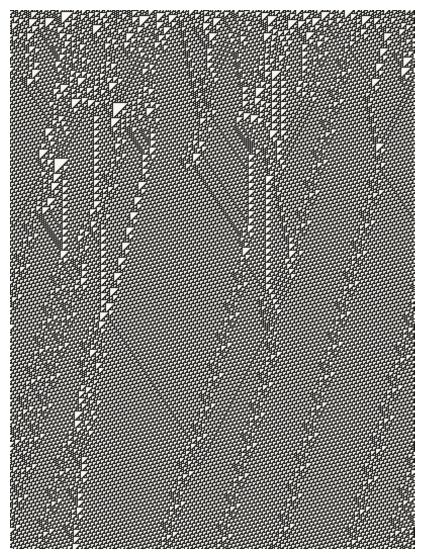

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch13_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the loom that taught machines to read

Computing's ancestry runs through art history, and specifically through textiles. In 1804 **Joseph Marie Jacquard** of Lyon perfected a loom attachment that read **punched cards**: each card row decided which warp threads lifted, so a chain of cards *was* the pattern, storable, copyable, editable. Decades later the technology wove its own showpiece, an 1839 silk portrait of Jacquard himself, programmed on roughly 24,000 cards; **Charles Babbage** proudly owned a copy, and his collaborator **Ada Lovelace** drew the connection that matters to us, writing in 1843 that the planned Analytical Engine "weaves algebraical patterns just as the Jacquard-loom weaves flowers and leaves" <a class="cite" href="#ref-lovelace1843">(Lovelace 1843)</a>. Punched cards went on to tabulate the 1890 US census on **Herman Hollerith**'s machines, and Hollerith's company folded into what became IBM: from ornament to data processing in three steps <a class="cite" href="#ref-essinger2004">(Essinger 2004)</a>. Weaving kept its algorithmic soul, too. At the Bauhaus and later at Black Mountain College <a class="cite" href="#ref-albersfoundation">(Josef and Anni Albers Foundation, biography)</a>, **Anni Albers** treated the weaving draft, the grid notation of over-or-under, as a binary compositional language, and her book *On Weaving* <a class="cite" href="#ref-albers1965">(1965)</a> reads in places like a programming manual for cloth.

The mathematics of grids of cells came from a different direction, beginning with John von Neumann's self-reproducing automata of the 1940s <a class="cite" href="#ref-vonneumann1966">(von Neumann 1966)</a>. In 1970, via Martin Gardner's *Scientific American* column, the mathematician **John Conway** published the **Game of Life** <a class="cite" href="#ref-gardner1970">(Gardner 1970)</a>, a two-dimensional world whose four-line rulebook produced gliders, oscillators, and eventually (Conway had offered 50 dollars for it) Bill Gosper's *glider gun*, a pattern that manufactures moving patterns forever <a class="cite" href="#ref-gardner1971">(Gardner 1971)</a>. Life escaped mathematics within months and never returned: over the years it became a screensaver, a hacker emblem <a class="cite" href="#ref-raymond2003">(Raymond 2003)</a>, and a philosophical toy about whether life itself might be rule-following at scale. In the 1980s **Stephen Wolfram** systematized the simplest possible case, the 256 *elementary* one-dimensional automata, sorted their behaviors into four classes <a class="cite" href="#ref-wolfram1984">(Wolfram 1984)</a>, and pointed out that **rule 30** produces disorder good enough to serve as a random number generator <a class="cite" href="#ref-wolfram1986">(Wolfram 1986)</a>, while looking uncannily like the pigmentation of the cone snail *Conus textile* <a class="cite" href="#ref-wolfram2002">(Wolfram 2002)</a>: nature, apparently, runs cellular automata on seashells. **Rule 110** went further: Matthew Cook proved (published 2004) that it can simulate any computation whatsoever <a class="cite" href="#ref-cook2004">(Cook 2004)</a>.

The concept these systems crystallize is **emergence** (Emergenz): structure at the large scale that is present nowhere in the small-scale rules. It is this course's fourth encounter with the theme, after chance (chapter 2), the Truchet grid's unplanned paths (chapter 4), and growth (chapter 7), and the most radical: nothing in rule 110's eight bits mentions triangles, yet triangles are what it makes. Hold on to the question of where, in that case, the pattern *comes from*; it returns with flocking in chapter 19.

## Eight bits of law: the rule table

An **elementary cellular automaton** (zellulärer Automat) lives on a row of cells, each 0 (paper) or 1 (ink). Time ticks row by row: a cell's next state depends only on its own state and its two neighbors', the three-cell **neighborhood**. Three binary cells have $2^3 = 8$ possible neighborhoods, so a rule is one answer (0 or 1) for each of the eight: eight bits, hence $2^8 = 256$ possible rules, numbered 0-255 by reading those answers as a binary number. Rule 30 decoded by hand, since $30 = 00011110_2$:

| neighborhood | 111 | 110 | 101 | 100 | 011 | 010 | 001 | 000 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| new cell | 0 | 0 | 0 | 1 | 1 | 1 | 1 | 0 |

Read the new-cell row left to right and you are reading the binary digits of the rule number itself: $00011110_2 = 16 + 8 + 4 + 2 = 30$ (the small $_2$ marks a binary number; its digits are worth 1, 2, 4, 8, 16..., doubling leftward, and only the digits showing 1 are added). The code below does this decoding for any rule number, using the bit-shift trick `(rule >> i) & 1`: two new operators, where `>> i` shifts a number's binary digits $i$ places to the right (dropping what falls off the end) and `& 1` keeps only the last remaining digit. The `:03b` in the print is a cousin of chapter 0's `:.2f`: it formats a number as three binary digits.

In [2]:
# decode a rule number into its eight answers, one per neighborhood
def rule_table(rule_number):
    table = []
    for i in range(8):
        table.append((rule_number >> i) & 1)     # bit i of the rule number
    return table                                 # table[n] answers neighborhood n

table = rule_table(30)
print("rule 30:")
for neighborhood in range(7, -1, -1):
    pattern = f"{neighborhood:03b}"
    print(f"  {pattern} -> {table[neighborhood]}")

rule 30:
  111 -> 0
  110 -> 0
  101 -> 0
  100 -> 1
  011 -> 1
  010 -> 1
  001 -> 1
  000 -> 0


Matches the hand-made table, good. Now evolution. For speed we update all cells at once with a vectorized trick worth learning: `np.roll` shifts a whole array one step left or right (wrapping around the edges, which conveniently makes our world a ring). Each cell then reads its neighborhood as the number $4\cdot\text{left} + 2\cdot\text{self} + \text{right}$, which is exactly an index into the rule table.

In [3]:
# evolve a starting row for many steps; stack the rows into a spacetime image
import numpy as np

def evolve(rule_number, steps, initial_row):
    table = np.array(rule_table(rule_number))
    rows = [initial_row]
    current = initial_row
    for step in range(steps):
        left = np.roll(current, 1)
        right = np.roll(current, -1)
        neighborhood = 4 * left + 2 * current + right
        current = table[neighborhood]            # everyone updates at once
        rows.append(current)
    return np.array(rows)

single_seed = np.zeros(301, dtype=int)
single_seed[150] = 1                             # one ink cell in the middle
spacetime = evolve(30, 150, single_seed)
print("spacetime image:", spacetime.shape, "(rows are time steps)")

spacetime image: (151, 301) (rows are time steps)


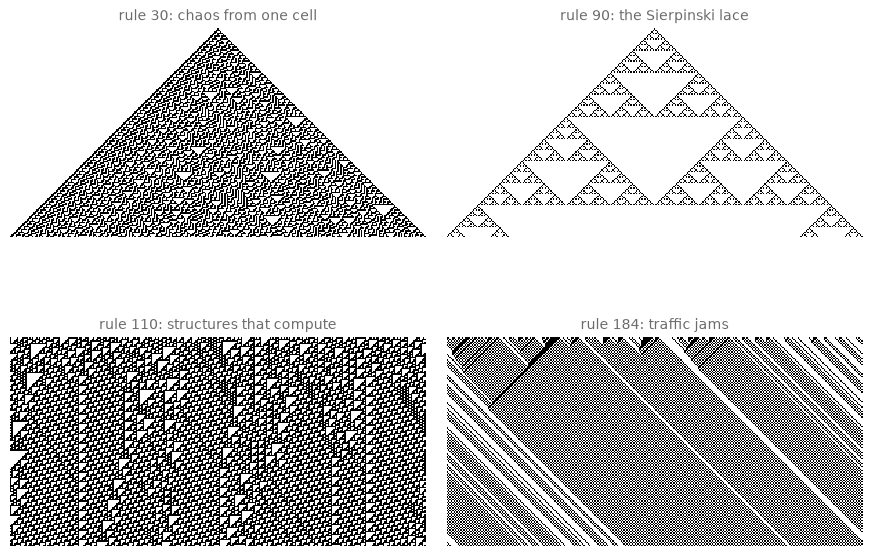

In [4]:
# four famous rules: two from one seed, two from random soup
import matplotlib.pyplot as plt

rng = np.random.default_rng(2)
random_row = rng.integers(0, 2, 301)

panels = [(30, single_seed, "rule 30: chaos from one cell"),
          (90, single_seed, "rule 90: the Sierpinski lace"),
          (110, random_row, "rule 110: structures that compute"),
          (184, rng.integers(0, 2, 301), "rule 184: traffic jams")]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, (rule, start, title) in zip(axes.flat, panels):
    ax.imshow(evolve(rule, 150, start), cmap="binary", interpolation="nearest")
    ax.set_title(title, fontsize=10, color="#6B6B6B")
    ax.axis("off")
fig.subplots_adjust(wspace=0.05, hspace=0.15)
plt.show()

Four rules, four personalities, spanning three of Wolfram's four classes; only the dullest class, the one that fades to uniformity, goes unrepresented. Rule 90 grows the Sierpinski triangle, self-similar like chapter 8's fractals (it is one, and a two-line program made it). Rule 30 boils: aperiodic, unpredictable, the seashell rule. Rule 110 is the strange one: local order, drifting particles, collisions that compute. Rule 184 is secretly a traffic model <a class="cite" href="#ref-nagel1996">(Nagel 1996)</a>, read each row as cars: the jams (thick black bands) move *backwards* while every car moves forward, a small emergence lesson all by itself.

**Try it.** Swap in rules 45, 73, 150, or any number under 256, with either starting row. Before running, guess from the binary digits whether you will get order or chaos. (You will be wrong often; that unpredictability from eight visible bits is Wolfram's whole point.)

## The weaving draft

Now dress the automaton as what it always was: a textile pattern. A weaving draft marks which threads cross over which; our spacetime diagram is exactly such a draft. Two changes of clothing take it there: a two-color palette instead of black on white, and a hair of space between cells, like threads in cloth. `pcolormesh` (a cousin of `imshow` that draws each cell as an outlined rectangle) provides the gaps.

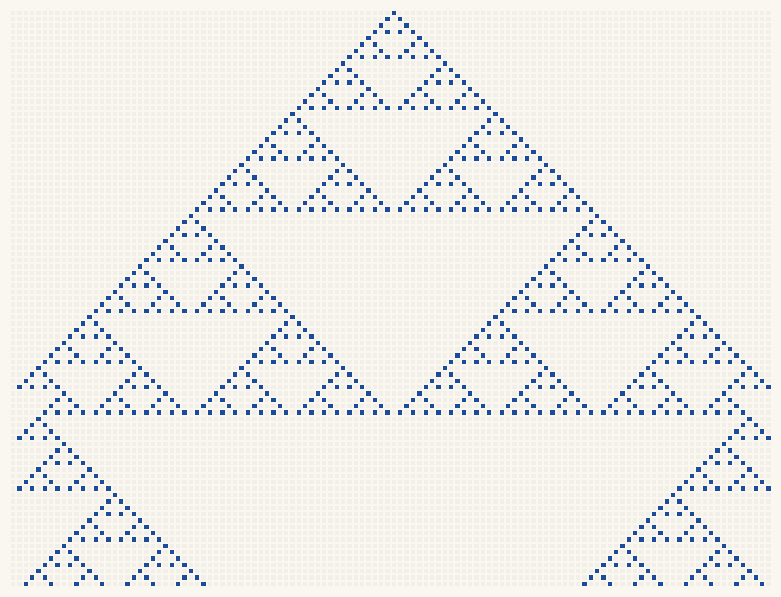

In [5]:
# an automaton in textile clothing: two yarn colors, hairline gaps
import sys
sys.path.append("..")
from matplotlib.colors import ListedColormap
from agap.helpers import PAPER, save_artwork

def ca_weave(rule_number, width=120, steps=90, colors=("#F2EFE9", "#1B4B9B"),
             random_start=False, seed=2):
    if random_start:
        rng = np.random.default_rng(seed)
        start = rng.integers(0, 2, width)
    else:
        start = np.zeros(width, dtype=int)
        start[width // 2] = 1
    fabric = evolve(rule_number, steps, start)
    fig, ax = plt.subplots(figsize=(10, 10 * steps / width), facecolor=PAPER)
    ax.pcolormesh(fabric[::-1], cmap=ListedColormap(colors),
                  edgecolors=PAPER, linewidth=0.35)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

art_1 = ca_weave(90, colors=("#F2EFE9", "#1B4B9B"))

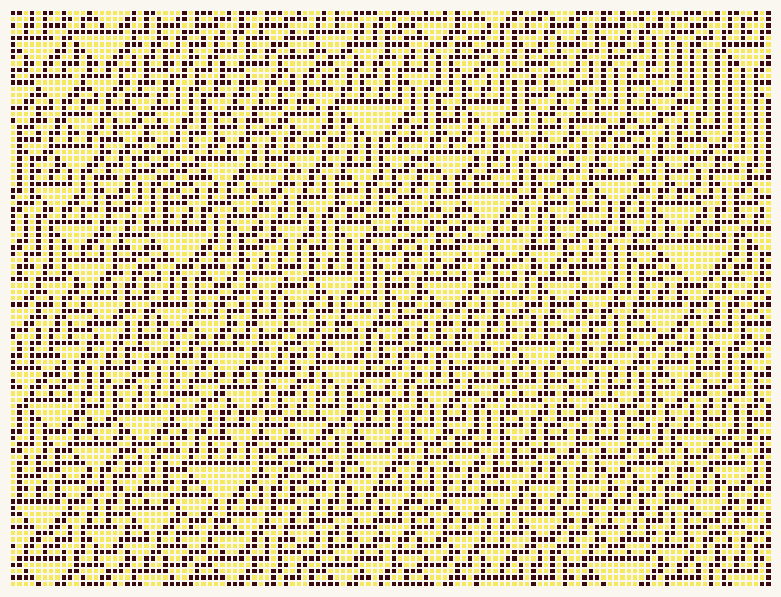

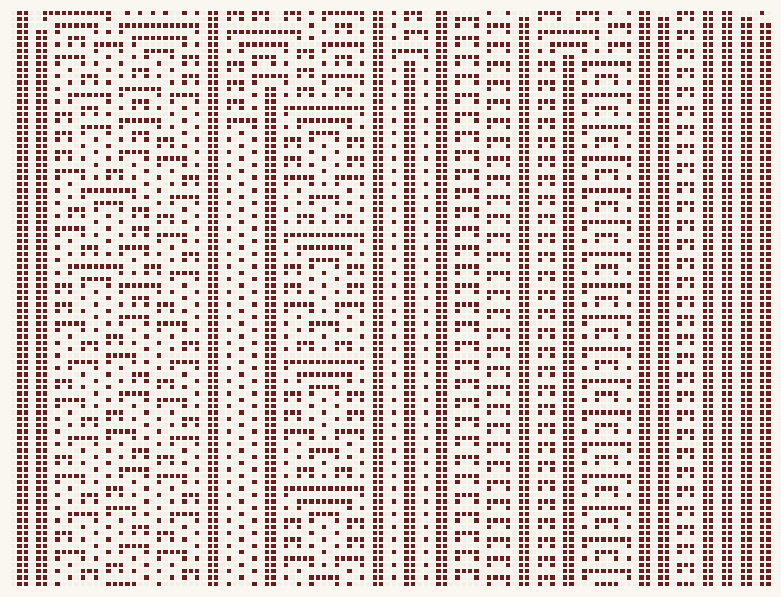

In [6]:
# temperament 2 and 3: chaos yarn, and rule 73's barred structures
art_2 = ca_weave(30, colors=("#F5E960", "#3B0A0E"), random_start=True, seed=5)
art_3 = ca_weave(73, colors=("#F2EFE9", "#701C1C"), random_start=True, seed=9)

**Look and compare.** Which of the three would you actually wear? Textile designers answered this question for centuries under a constraint our screen ignores: a loom's pattern must behave *everywhere*, no lucky crops. Notice how rule 73's walls and ladders feel woven while rule 30 feels printed; can you say why in terms of repetition? And connect backwards: these grids are chapter 2's color grids again, except no cell was chosen by chance; every single pixel is law.

## The Game of Life

Two dimensions now. Conway's **Game of Life** upgrades the neighborhood to all eight surrounding cells and uses one rulebook, named **B3/S23** in the automata trade: a dead cell with exactly 3 live neighbors is **B**orn; a live cell with 2 or 3 live neighbors **S**urvives; everything else dies (loneliness or overcrowding). Counting eight neighbors for every cell at once is a job for `scipy.ndimage.convolve`, the sliding-window workhorse: slide a 3x3 ring of ones over the grid, and each cell receives its neighbor count. Remember this function; it carries all of chapter 14 and returns in chapter 16.

In [7]:
# one Life step: convolve counts neighbors, the B3/S23 rulebook decides
from scipy.ndimage import convolve

NEIGHBORS = np.array([[1, 1, 1],
                      [1, 0, 1],
                      [1, 1, 1]])

def life_step(grid):
    count = convolve(grid, NEIGHBORS, mode="wrap")
    birth = (grid == 0) & (count == 3)
    survive = (grid == 1) & ((count == 2) | (count == 3))
    return (birth | survive).astype(int)

rng = np.random.default_rng(11)
soup = (rng.random((100, 100)) < 0.35).astype(int)   # 35% alive at the start
print("living cells at start:", soup.sum())

living cells at start: 3580


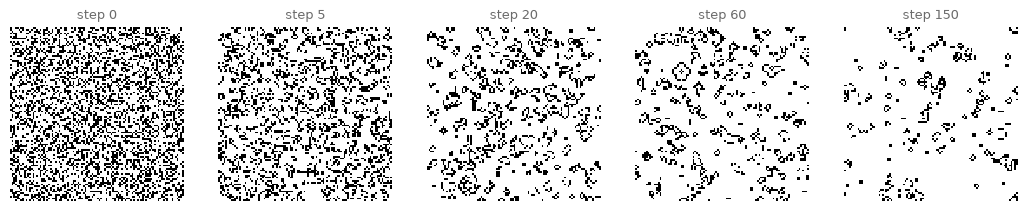

In [8]:
# five snapshots of the soup settling into gliders, blinkers, still lifes
snapshots = [0, 5, 20, 60, 150]
grid = soup.copy()
frames = {0: grid.copy()}
for step in range(1, max(snapshots) + 1):
    grid = life_step(grid)
    if step in snapshots:
        frames[step] = grid.copy()

fig, axes = plt.subplots(1, 5, figsize=(13, 2.9))
for ax, step in zip(axes, snapshots):
    ax.imshow(frames[step], cmap="binary", interpolation="nearest")
    ax.set_title(f"step {step}", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

The early steps churn; by step 150 the world has cooled into a sparse ecology of stable blocks, blinking pairs, and the occasional glider crawling off on its own.

**Try it.** The soup's density is the `< 0.35` in the seeding cell. Try `0.10` and `0.60` (rerun both cells above): when is the world stillborn, and when does it choke before it can organize? Stills undersell this; Life wants to move. The next cell writes the whole run as an animated GIF with chapter 12's `imageio` export, scaling each frame up with `np.kron`, which replaces every cell by a 4x4 block of itself: pixel art's zoom.

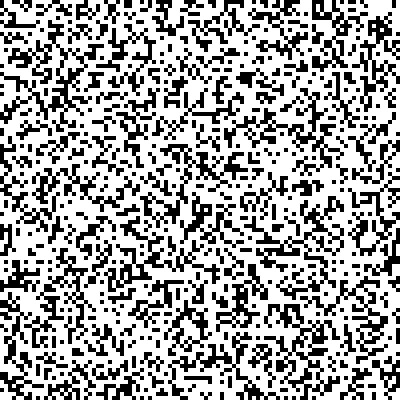

In [9]:
# export the run as an animated GIF and show it inline
import imageio.v2 as imageio
from IPython.display import Image as GifImage

grid = soup.copy()
gif_frames = []
for step in range(200):
    big = np.kron(1 - grid, np.ones((4, 4), dtype=int)) * 255
    gif_frames.append(big.astype(np.uint8))      # 1 - grid: ink cells dark
    grid = life_step(grid)

gif_path = "../assets/outputs/ch13_life.gif"
imageio.mimsave(gif_path, gif_frames, fps=12, loop=0)
GifImage(filename=gif_path)

## The gun that Conway bet against

Conway initially conjectured that no pattern could grow forever, and put 50 dollars on it <a class="cite" href="#ref-gardner1970">(Gardner 1970)</a>. Within the year, Bill Gosper's group at MIT found the counterexample: the **glider gun**, a factory of thirty-six cells that fires a glider every thirty steps, forever (<a class="cite" href="#ref-gardner1971">Gardner 1971</a>; <a class="cite" href="#ref-lifewikigun">LifeWiki, "Gosper glider gun"</a>). Here it is, hardcoded cell by cell, the way patterns circulated in 1970s newsletters.

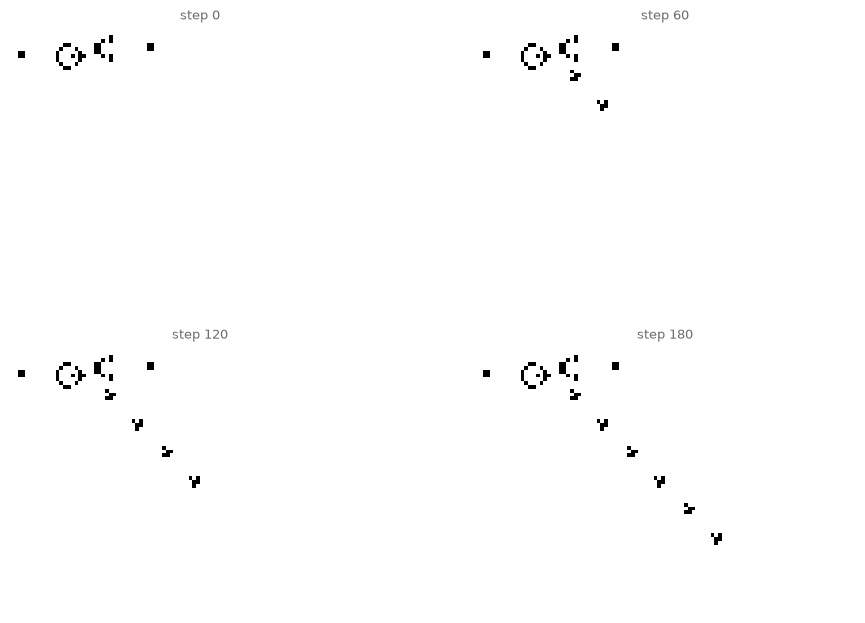

In [10]:
# the Gosper glider gun: 36 cells that manufacture motion forever
GUN = [(4, 0), (5, 0), (4, 1), (5, 1), (4, 10), (5, 10), (6, 10), (3, 11),
       (7, 11), (2, 12), (8, 12), (2, 13), (8, 13), (5, 14), (3, 15), (7, 15),
       (4, 16), (5, 16), (6, 16), (5, 17), (2, 20), (3, 20), (4, 20), (2, 21),
       (3, 21), (4, 21), (1, 22), (5, 22), (0, 24), (1, 24), (5, 24), (6, 24),
       (2, 34), (3, 34), (2, 35), (3, 35)]

world = np.zeros((70, 100), dtype=int)
for row, column in GUN:
    world[row + 2, column + 2] = 1

stages = {}
for step in range(181):
    if step in (0, 60, 120, 180):
        stages[step] = world.copy()
    world[0, :] = world[-1, :] = 0               # gliders die at the border
    world[:, 0] = world[:, -1] = 0
    world = life_step(world)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.6))
for ax, step in zip(axes.flat, stages):
    ax.imshow(stages[step], cmap="binary", interpolation="nearest")
    ax.set_title(f"step {step}", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

By step 60 the first gliders are away; by 180 a procession marches toward the corner, where our hard border quietly retires them. A pattern that *produces* patterns: the gun settled the growth bet, and it also settled something deeper, since streams of gliders can carry bits, and crossing streams can compute. Life is, like rule 110, a universal computer <a class="cite" href="#ref-berlekamp1982">(Berlekamp et al. 1982)</a>, and everything on this screen today is in principle buildable inside it.

## Export your artwork

Weave a rule of your own choosing in your own two yarns (any rule number under 256, any two hex colors, single seed or soup). Replace `yourname` and run; the print-quality PNG lands in `assets/outputs/`.

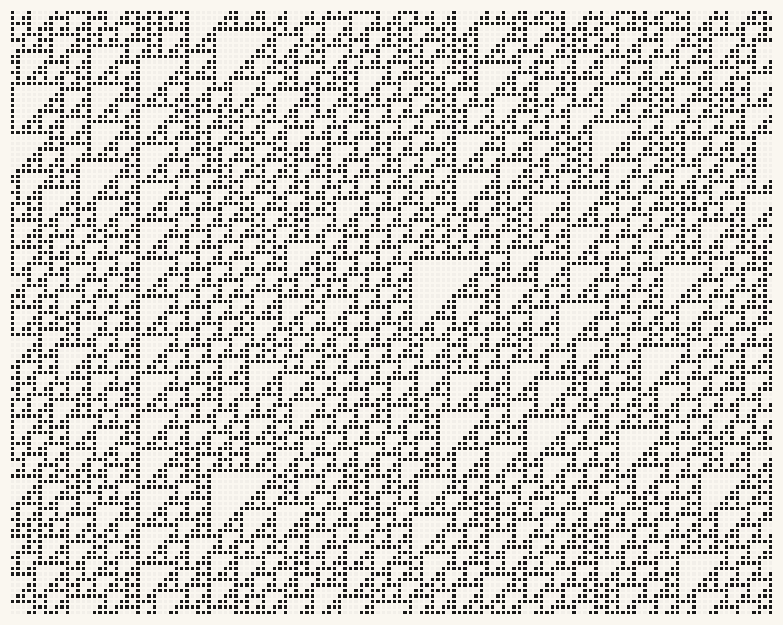

saved: assets/outputs/ch13_yourname.png


In [11]:
# save YOUR artwork: adjust rule, colors and start, replace 'yourname', run
my_artwork = ca_weave(110, width=140, steps=110,
                      colors=("#F2EFE9", "#1A1A1A"), random_start=True,
                      seed=2026)
saved_path = save_artwork(my_artwork, "yourname", chapter=13)

## Exercises

**(a) Parameter exploration: the rule census.** Render all 256 elementary rules from a single seed as tiny thumbnails in a 16x16 grid (small width, few steps; a double loop over subplots does it). Pick your top three purely aesthetically and defend the choices in one sentence each. Then check: are your favorites orderly, chaotic, or on the edge? Most people's picks cluster at the edge of chaos, which is itself a finding about taste.

**(b) Code modification: Day & Night.** Life is one point in a space of rulebooks. Implement **B3678/S34678** (born with 3, 6, 7 or 8 neighbors; surviving with 3, 4, 6, 7 or 8), known as *Day & Night* <a class="cite" href="#ref-lifewikiday">(LifeWiki, "Day & Night")</a> because its ink and paper behave symmetrically: run it from a soup and watch continents with smooth coastlines form and erode. `np.isin(count, [3, 6, 7, 8])` spares you a chain of comparisons.

<details><summary>Solution</summary>

```python
def day_and_night_step(grid):
    count = convolve(grid, NEIGHBORS, mode="wrap")
    birth = (grid == 0) & np.isin(count, [3, 6, 7, 8])
    survive = (grid == 1) & np.isin(count, [3, 4, 6, 7, 8])
    return (birth | survive).astype(int)

rng = np.random.default_rng(7)
grid = (rng.random((160, 160)) < 0.5).astype(int)
shots = {}
for step in range(301):
    if step in (0, 30, 300):
        shots[step] = grid.copy()
    grid = day_and_night_step(grid)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, step in zip(axes, shots):
    ax.imshow(shots[step], cmap="binary", interpolation="nearest")
    ax.set_title(f"step {step}", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()
```

The 50% soup organizes into black and white territories whose borders round themselves off like surface tension. Swap every 0 for 1 in the start grid and the film plays identically with colors exchanged; that symmetry is baked into the rule numbers, and nothing in Life has it.
</details>

**(c) Creative challenge: a painting decays.** Load `monet_waterlilies.jpg` (chapter 6 shows how), downscale it hard, threshold its darkness into a starting grid (`grid = (gray < 0.5).astype(int)`), and let Life run on the painting. Export the frame where the Monet is still *just* recognizable: the moment between image and ecology. A GIF of the full decay makes a fine gallery entry, and a fine metaphor.

## Further reading

- Martin Gardner, "The fantastic combinations of John Conway's new solitaire game 'life'", *Scientific American*, October 1970: the column that released Life into the world; short and still delightful.
- Anni Albers, *On Weaving* (1965): grids, notation, and pattern thought through by hand, decades before pixels; read chapter and plate side by side with today's outputs.
- The [LifeWiki](https://conwaylife.com/wiki/): thousands of catalogued patterns with animations, from the glider to computers built inside Life.
- Stephen Wolfram, *A New Kind of Science* (2002), [free online](https://www.wolframscience.com/nks/): the elementary automata in obsessive depth; browse chapter 2 for the rule zoo and the shell.

## References

- <span id="ref-albers1965"></span>Albers, A. (1965). *On Weaving*. Wesleyan University Press. Grids, notation, and pattern thought through by hand; also this chapter's Further Reading.
- <span id="ref-berlekamp1982"></span>Berlekamp, E. R., Conway, J. H., and Guy, R. K. (1982). *Winning Ways for Your Mathematical Plays*, vol. 2. Academic Press. Chapter 25, "What Is Life?", sketches the computer built of glider streams.
- <span id="ref-cook2004"></span>Cook, M. (2004). Universality in elementary cellular automata. *Complex Systems*, 15(1), 1–40. [Journal page](https://www.complex-systems.com/abstracts/v15_i01_a01/). The rule 110 universality proof.
- <span id="ref-essinger2004"></span>Essinger, J. (2004). *Jacquard's Web: How a Hand-Loom Led to the Birth of the Information Age*. Oxford University Press. The whole chain: loom, woven portrait, Babbage, Hollerith, IBM.
- <span id="ref-gardner1970"></span>Gardner, M. (1970). Mathematical Games: The fantastic combinations of John Conway's new solitaire game "life". *Scientific American*, 223(4), 120–123. [doi:10.1038/scientificamerican1070-120](https://doi.org/10.1038/scientificamerican1070-120). The column that released Life, 50-dollar wager included.
- <span id="ref-gardner1971"></span>Gardner, M. (1971). Mathematical Games: On cellular automata, self-reproduction, the Garden of Eden and the game "life". *Scientific American*, 224(2), 112–117. Reports Gosper's glider gun and the settled bet.
- <span id="ref-albersfoundation"></span>Josef and Anni Albers Foundation. Anni Albers: biography. [albersfoundation.org/alberses/biography](https://www.albersfoundation.org/alberses/biography). Bauhaus weaving workshop 1922–32, Black Mountain College 1933–49.
- <span id="ref-lifewikiday"></span>LifeWiki. Day & Night. [conwaylife.com/wiki/OCA:Day_%26_Night](https://conwaylife.com/wiki/OCA:Day_%26_Night). The rule's catalogue entry, its ink-paper symmetry included.
- <span id="ref-lifewikigun"></span>LifeWiki. Gosper glider gun. [conwaylife.com/wiki/Gosper_glider_gun](https://conwaylife.com/wiki/Gosper_glider_gun). Cell count, period, and history of the gun.
- <span id="ref-lovelace1843"></span>Lovelace, A. A. (1843). Notes by the translator, appended to Menabrea, L. F., Sketch of the Analytical Engine invented by Charles Babbage. *Taylor's Scientific Memoirs*, 3, 666–731. [Full text at fourmilab.ch](https://www.fourmilab.ch/babbage/sketch.html). The weaving sentence is in Note A.
- <span id="ref-nagel1996"></span>Nagel, K. (1996). Particle hopping models and traffic flow theory. *Physical Review E*, 53(5), 4655–4672. [doi:10.1103/PhysRevE.53.4655](https://doi.org/10.1103/PhysRevE.53.4655). Places rule 184, the minimal deterministic model, within traffic-flow theory.
- <span id="ref-raymond2003"></span>Raymond, E. S. (2003). The glider: an Appropriate Hacker Emblem. [catb.org/hacker-emblem](http://www.catb.org/hacker-emblem/). The October 2003 proposal itself.
- <span id="ref-vonneumann1966"></span>von Neumann, J. (1966). *Theory of Self-Reproducing Automata* (edited and completed by A. W. Burks). University of Illinois Press. The 1940s self-reproduction work in book form.
- <span id="ref-wolfram1984"></span>Wolfram, S. (1984). Universality and complexity in cellular automata. *Physica D*, 10(1–2), 1–35. [doi:10.1016/0167-2789(84)90245-8](https://doi.org/10.1016/0167-2789(84)90245-8). The four classes of elementary-automaton behavior.
- <span id="ref-wolfram1986"></span>Wolfram, S. (1986). Random sequence generation by cellular automata. *Advances in Applied Mathematics*, 7(2), 123–169. [doi:10.1016/0196-8858(86)90028-X](https://doi.org/10.1016/0196-8858(86)90028-X). Rule 30 as a random number generator.
- <span id="ref-wolfram2002"></span>Wolfram, S. (2002). *A New Kind of Science*. Wolfram Media. [Free online](https://www.wolframscience.com/nks/). Page 423 sets mollusc-shell pigmentation, the textile cone included, beside one-dimensional automaton output.


---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: rule 110 at loom width, ink on paper. It runs automatically with *Restart & Run All*.

saved: assets/outputs/ch13_showpiece.png


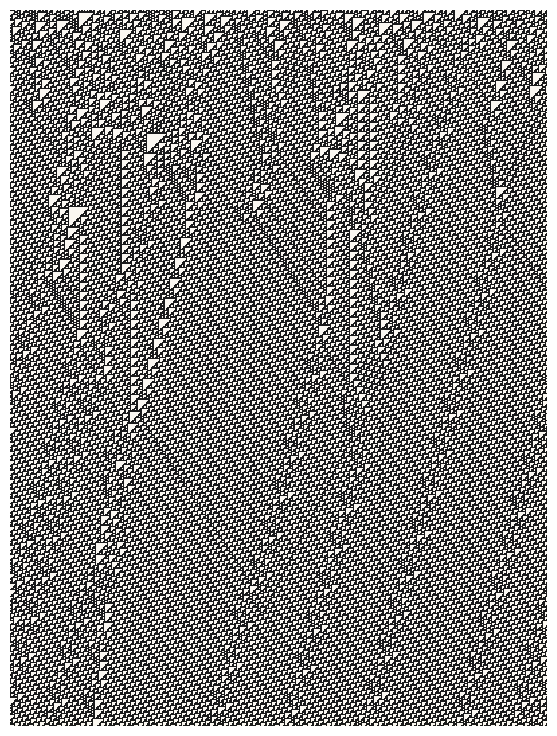

In [12]:
# regenerate this chapter's showpiece: rule 110 as a large two-tone weave
from matplotlib.colors import to_rgb

rng = np.random.default_rng(110)
start = rng.integers(0, 2, 400)
fabric = evolve(110, 532, start)

big = np.kron(fabric, np.ones((5, 5), dtype=int))          # 5x pixel zoom
ink = (np.array(to_rgb("#1A1A1A")) * 255).astype(np.uint8)
paper = (np.array(to_rgb(PAPER)) * 255).astype(np.uint8)
showpiece = np.empty(big.shape + (3,), dtype=np.uint8)
showpiece[big == 0] = paper
showpiece[big == 1] = ink
saved_path = save_artwork(showpiece, "showpiece", chapter=13)

plt.figure(figsize=(7, 9.3))
plt.imshow(showpiece, interpolation="nearest")
plt.axis("off")
plt.show()